<a href="https://colab.research.google.com/github/Arlan999qi/AI-Univariate-Linear-Regression/blob/main/Kratosclassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install -Uqq fastai
!pip install -Uqq icrawler

In [11]:
from icrawler.builtin import BingImageCrawler
import logging

def search_images(term, max_images=30):
    print(f"Searching for '{term}' using Bing...")
    # We use a temporary folder for the crawler to work in
    temp_dir = f'cache_{term.replace(" ", "_")}'

    # Set up the crawler (turning off logging to keep it clean)
    google_crawler = BingImageCrawler(storage={'root_dir': temp_dir}, log_level=logging.ERROR)
    google_crawler.crawl(keyword=term, max_num=max_images)

    # Get the list of file paths created
    from fastcore.all import L
    from pathlib import Path

    # Return the file paths as strings so the rest of Jeremy's code works
    return L(Path(temp_dir).ls()).map(str)

Searching for 'kratos god of war' using Bing...


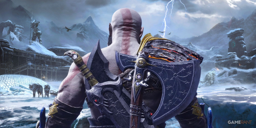

In [12]:
# Search for Kratos
urls = search_images('kratos god of war', max_images=1)
dest = 'kratos.jpg'

# Since the function above already downloaded the file to a cache,
# we can just grab the first one:
import shutil
shutil.copy(urls[0], dest)

# View it
from fastai.vision.all import *
im = Image.open(dest)
im.to_thumb(256,256)

Searching for 'Arthur Morgan' using Bing...


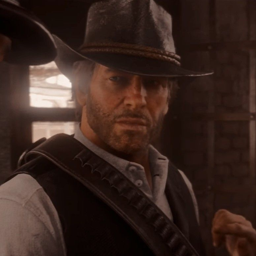

In [13]:
# Search for Kratos
urls = search_images('Arthur Morgan', max_images=1)
dest = 'arthurmorgan.jpg'

# Since the function above already downloaded the file to a cache,
# we can just grab the first one:
import shutil
shutil.copy(urls[0], dest)

# View it
from fastai.vision.all import *
im = Image.open(dest)
im.to_thumb(256,256)

In [14]:
searches = 'kratos','arthur morgan'
path = Path('kratos_or_not')

for o in searches:
    dest = (path/o)
    dest.mkdir(exist_ok=True, parents=True)

    # 1. Search AND download using our Bing function
    # This returns a list of local file paths
    results = search_images(f'{o} photo', max_images=400)

    # 2. Move the downloaded files to the correct 'dest' folder
    for i, file_path in enumerate(results):
        try:
            # We move the file to your 'path/o' directory with a clean name
            shutil.move(file_path, dest/f'image_{i}.jpg')
        except:
            continue

    # 3. Clean up the empty cache folder left behind by the search
    temp_cache = Path(f'cache_{o.replace(" ", "_")}_photo')
    if temp_cache.exists(): shutil.rmtree(temp_cache)

    # 4. Jeremy's resizing step
    resize_images(dest, max_size=400, dest=dest)

print("Done! Your images are organized and resized.")

Searching for 'kratos photo' using Bing...


ERROR:downloader:Response status code 403, file https://preview.redd.it/kratos-had-fun-photoshoot-v0-1kcxy5n53ata1.jpg
ERROR:downloader:Response status code 403, file https://images.wallpapersden.com/image/download/kratos-colorful-head-hd-god-of-war_bmdrZWmUmZqaraWkpJRnbmZnrWZraGc.jpg
ERROR:downloader:Response status code 403, file https://wallpapercrafter.com/desktop1/649530-Kratos-God-of-War-god-war-x-video-games-hd.jpg
ERROR:downloader:Response status code 403, file https://wallpapercrafter.com/desktop/77196-kratos-god-of-war-4-god-of-war-games-ps-games-hd-4k.jpg


Searching for 'arthur morgan photo' using Bing...


ERROR:downloader:Response status code 401, file https://images-wixmp-ed30a86b8c4ca887773594c2.wixmp.com/f/5ddfd475-7161-4b2d-9474-db9fe8650ff2/dg7t0af-af47496b-3acb-45f9-b275-12ec4344d3b4.png/v1/fill/w_1280,h_1565,q_80,strp/arthur_morgan_by_ilsirya_dg7t0af-fullview.jpg
ERROR:downloader:Response status code 401, file https://images-wixmp-ed30a86b8c4ca887773594c2.wixmp.com/f/b6a76081-0168-4c03-b382-42ab56bf14b9/dg7ym52-4ec50e02-7414-473e-ba00-a19428c9ec70.jpg
ERROR:downloader:Response status code 401, file https://images-wixmp-ed30a86b8c4ca887773594c2.wixmp.com/f/741ace11-24fd-4400-803e-491cc23702c7/dfj2vcj-d644684f-7b22-4309-8783-38f385ffed1c.png/v1/fill/w_894,h_894,q_70,strp/arthur_morgan_by_serbiandude_dfj2vcj-pre.jpg
ERROR:downloader:Response status code 401, file https://images-wixmp-ed30a86b8c4ca887773594c2.wixmp.com/f/2d3dc87a-b314-4fd8-b1a8-3697f82c4c83/dj065kz-c609e184-4482-4eac-a44b-cb77646d4507.png/v1/fill/w_894,h_894,q_70,strp/arthur_morgan_by_neserjesno_dj065kz-pre.jpg
ERROR

Done! Your images are organized and resized.


In [15]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

0

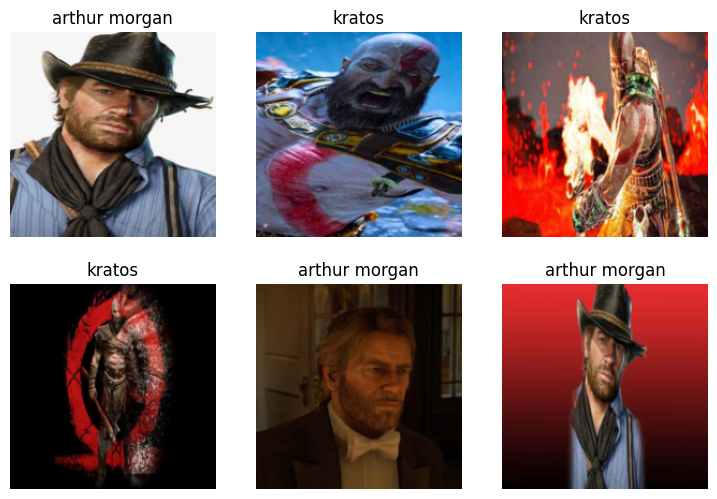

In [16]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)
dls.show_batch(max_n=6)

In [17]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,1.676535,0.850900,0.500000,00:16


epoch,train_loss,valid_loss,error_rate,time
0,0.986393,0.377559,0.250000,00:17
1,0.669537,0.101062,0.000000,00:21
2,0.500306,0.032098,0.000000,00:24


In [29]:
is_kratos,_,probs = learn.predict(PILImage.create('kratos.jpg'))
print(f"This is a {is_kratos.title()}")
print(f"Probability this is Kratos is {probs[probs.argmax()]:.4f}")

This is a Kratos
Probability this is Kratos is 0.9999
